In [1]:
# The dataset does not provide an actual date of default.
# We therefore do not pretend that last_statement is default time.
#
# Instead, survival methods are used to study time until
# an observable high-risk state appears in statement history.

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sqlalchemy import create_engine
from dotenv import load_dotenv

from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter,
)

from lifelines.statistics import (
    multivariate_logrank_test,
)

from sklearn.preprocessing import (
    StandardScaler,
)


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


load_dotenv(
    PROJECT_ROOT / ".env"
)


engine = create_engine(
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_USER', 'ahadke')}:"
    f"{os.getenv('DB_PASSWORD', '')}@"
    f"{os.getenv('DB_HOST', 'localhost')}:"
    f"{os.getenv('DB_PORT', '5432')}/"
    f"{os.getenv('DB_NAME', 'amex_credit_risk')}"
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


In [2]:
shortlist = pd.read_csv(
    PROCESSED_DIR
    / "statistical_shortlist.csv"
)


selected_features = (
    shortlist[
        "feature"
    ]
    .head(8)
    .tolist()
)


print(
    "Features used:",
    selected_features,
)

Features used: ['P_2', 'D_44', 'B_2', 'B_1', 'B_9', 'S_3', 'D_45', 'R_1']


In [3]:
columns_sql = ", ".join(
    [
        f'f."{feature}"'
        for feature
        in selected_features
    ]
)


query = f"""
SELECT
    f."customer_ID",
    f.statement_date,
    {columns_sql},
    d.target

FROM fact_statements f

JOIN dim_customer d
  ON f."customer_ID" = d."customer_ID"

ORDER BY
    f."customer_ID",
    f.statement_date
"""


history = pd.read_sql(
    query,
    engine,
)


history[
    "statement_date"
] = pd.to_datetime(
    history[
        "statement_date"
    ]
)

In [4]:
# Every customer receives their own longitudinal clock.

history[
    "first_date"
] = history.groupby(
    "customer_ID"
)[
    "statement_date"
].transform(
    "min"
)


history[
    "months_since_first"
] = (
    (
        history[
            "statement_date"
        ]
        - history[
            "first_date"
        ]
    ).dt.days
    / 30.44
)

In [5]:
# The strongest statistically ranked feature
# becomes our risk-transition indicator.

risk_feature = (
    selected_features[0]
)


default_median = (
    history.loc[
        history[
            "target"
        ] == 1,
        risk_feature,
    ]
    .median()
)


non_default_median = (
    history.loc[
        history[
            "target"
        ] == 0,
        risk_feature,
    ]
    .median()
)


higher_is_riskier = (
    default_median
    > non_default_median
)


print(
    "Risk feature:",
    risk_feature,
)

print(
    "Higher values appear riskier:",
    higher_is_riskier,
)

Risk feature: P_2
Higher values appear riskier: False


In [6]:
# Thresholds are defined from each customer's baseline statement
# rather than future values.

baseline = (
    history
    .sort_values(
        [
            "customer_ID",
            "statement_date",
        ]
    )
    .groupby(
        "customer_ID",
        as_index=False,
    )
    .first()
)


if higher_is_riskier:

    threshold = (
        baseline[
            risk_feature
        ]
        .quantile(
            0.75
        )
    )

    history[
        "risk_event"
    ] = (
        history[
            risk_feature
        ] >= threshold
    )

else:

    threshold = (
        baseline[
            risk_feature
        ]
        .quantile(
            0.25
        )
    )

    history[
        "risk_event"
    ] = (
        history[
            risk_feature
        ] <= threshold
    )


print(
    "Risk-event threshold:",
    threshold,
)

Risk-event threshold: 0.4815368426953194


In [7]:
event_time = (
    history.loc[
        history[
            "risk_event"
        ]
    ]
    .groupby(
        "customer_ID"
    )[
        "months_since_first"
    ]
    .min()
    .rename(
        "event_time"
    )
)


last_time = (
    history
    .groupby(
        "customer_ID"
    )[
        "months_since_first"
    ]
    .max()
    .rename(
        "last_time"
    )
)


survival_df = (
    baseline[
        [
            "customer_ID",
            "target",
        ]
        + selected_features
    ]
    .set_index(
        "customer_ID"
    )
    .join(
        event_time
    )
    .join(
        last_time
    )
)


survival_df[
    "event"
] = (
    survival_df[
        "event_time"
    ]
    .notna()
    .astype(int)
)


survival_df[
    "duration"
] = (
    survival_df[
        "event_time"
    ]
    .fillna(
        survival_df[
            "last_time"
        ]
    )
    .clip(
        lower=0.01
    )
)


survival_df = (
    survival_df
    .reset_index()
)

In [8]:
survival_df[
    "baseline_quartile"
] = pd.qcut(
    survival_df[
        risk_feature
    ],
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4",
    ],
    duplicates="drop",
)

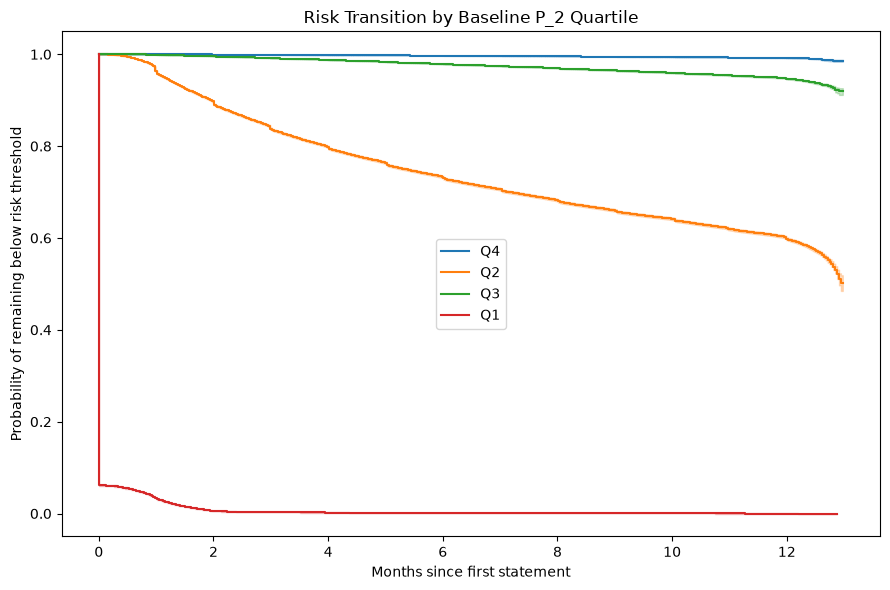

In [9]:
kmf = KaplanMeierFitter()


plt.figure(
    figsize=(9, 6)
)


for quartile in (
    survival_df[
        "baseline_quartile"
    ]
    .dropna()
    .unique()
):

    mask = (
        survival_df[
            "baseline_quartile"
        ] == quartile
    )

    kmf.fit(
        survival_df.loc[
            mask,
            "duration",
        ],
        event_observed=
            survival_df.loc[
                mask,
                "event",
            ],
        label=str(
            quartile
        ),
    )

    kmf.plot_survival_function()


plt.xlabel(
    "Months since first statement"
)

plt.ylabel(
    "Probability of remaining below risk threshold"
)

plt.title(
    f"Risk Transition by Baseline {risk_feature} Quartile"
)

plt.tight_layout()
plt.show()

In [10]:
logrank = multivariate_logrank_test(
    survival_df[
        "duration"
    ],
    survival_df[
        "baseline_quartile"
    ],
    survival_df[
        "event"
    ],
)


print(
    "Log-rank p-value:",
    logrank.p_value,
)

Log-rank p-value: 0.0


In [11]:
# Cox regression estimates associations with
# faster or slower transition into the defined high-risk state.

cox_features = [
    feature
    for feature
    in selected_features
    if survival_df[
        feature
    ].notna().mean() >= 0.40
]


cox_df = survival_df[
    [
        "duration",
        "event",
    ]
    + cox_features
].copy()


for feature in cox_features:

    cox_df[
        feature
    ] = (
        cox_df[
            feature
        ]
        .fillna(
            cox_df[
                feature
            ].median()
        )
    )


scaler = StandardScaler()


cox_df[
    cox_features
] = scaler.fit_transform(
    cox_df[
        cox_features
    ]
)

In [12]:
cph = CoxPHFitter(
    penalizer=0.01
)


cph.fit(
    cox_df,
    duration_col="duration",
    event_col="event",
)


cox_results = (
    cph.summary[
        [
            "coef",
            "exp(coef)",
            "p",
        ]
    ]
    .rename(
        columns={
            "exp(coef)":
                "hazard_ratio",
        }
    )
)


cox_results

,coef,hazard_ratio,p
covariate,,,
P_2,-1.495643,0.224104,0.000000e+00
D_44,0.101329,1.106641,0.000000e+00
B_2,-0.082676,0.920649,5.190000e-171
B_1,-0.001651,0.998350,4.942512e-01
B_9,0.056845,1.058491,4.097713e-230
S_3,0.080597,1.083934,0.000000e+00
D_45,-0.325767,0.721973,0.000000e+00
R_1,-0.110548,0.895343,0.000000e+00


In [13]:
# HR above 1 means faster transition into the proxy risk state.
# HR below 1 means slower transition.
# These are not causal default effects.

cph.check_assumptions(
    cox_df,
    p_value_threshold=0.05,
    show_plots=False,
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'P_2' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'P_2' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'P_2' using pd.cut, and then specify it in `strata=['P_2',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'D_44' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'D_44' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try bin

[]

In [14]:
proxy_target_relationship = (
    survival_df
    .groupby(
        "event",
        as_index=False,
    )
    .agg(
        customers=(
            "customer_ID",
            "count",
        ),
        default_rate=(
            "target",
            "mean",
        ),
    )
)


print(proxy_target_relationship)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

survival_df.to_parquet(
    PROCESSED_DIR / "survival_proxy_dataset.parquet",
    index=False,
)

cox_results.to_csv(
    PROCESSED_DIR / "cox_risk_transition_results.csv",
)

print("Survival analysis outputs saved.")
print(f"Proxy rows: {len(survival_df):,}")
print(f"Event rate: {survival_df['event'].mean():.4%}")


   event  customers  default_rate
0      0     294842      0.065706
1      1     164071      0.606170


Survival analysis outputs saved.
Proxy rows: 458,913
Event rate: 35.7521%


## Summary

This notebook is **time-to-observed-risk-transition**, not time-to-default. AMEX does not provide a default date, so last-statement minus first-statement with `target` as the event is not used.

**What we did**
- Took the top 8 shortlisted features and pulled complete statement histories from `fact_statements`.
- Chose the strongest feature (**P_2**) and compared default vs non-default medians to decide direction.
- Set a baseline-derived threshold (25th percentile of first-statement **P_2**, because lower P_2 is riskier).
- Defined the event as first crossing of that threshold; customers who never cross are censored.
- Used duration 0.01 when needed; `qcut(..., duplicates="drop")` for baseline quartiles.
- Plotted Kaplan–Meier curves, ran a log-rank test, fit Cox PH, checked PH assumptions, and compared the proxy event to actual `target`.

**Results**
- Risk feature: **P_2**. Higher values are **not** riskier. Threshold: **0.482**.
- Proxy dataset: **458,913** customers. Event rate **35.75%**. Duration minimum 0.01.
- Log-rank p-value: **0**.
- Cox hazard ratios (selected): **P_2** 0.224, **D_45** 0.722, **D_44** 1.107, **B_1** 0.998 (p = 0.49). Several covariates failed the PH test.
- Proxy event vs actual default: no-event default rate **6.57%** (294,842 customers); event default rate **60.62%** (164,071 customers).

Outputs: `survival_proxy_dataset.parquet`, `cox_risk_transition_results.csv`. Cox HRs describe faster/slower entry into the proxy risk state, not causal default timing.